## Assignment 1: Word Count

In this assignment, you will identify the most popular words appearing in the paper Detecting Covid19 Fake News. You will create a word cloud to visualize the results. You will first upload the file covid19_fake_news_detection.txt to the hpc server.

In [4]:
from pyspark.sql import SparkSession

# change the account name to your email account
account='sli'

# define a root path to access the data in isa540 folder
root_path='/net/clusterhn/home/'+account+'/isa460_sli/Data/'

# create a spark session
spark = (SparkSession.builder.appName("My First Spark Program")
       .config("spark.port.maxRetries", "100")
       .getOrCreate())

# confiture the log level (defaulty is WWARN)
spark.sparkContext.setLogLevel('ERROR')

# read the csv file

book = spark.read.text(root_path+"covid19_fake_news_detection.txt")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/09/29 10:48:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/09/29 10:48:13 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/09/29 10:48:13 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
25/09/29 10:48:13 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
25/09/29 10:48:13 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.
25/09/29 10:48:13 WARN Utils: Service 'SparkUI' could not bind on port 4044. Attempting port 4045.
25/09/29 10:48:13 WARN Utils: Service 'SparkUI' could not bind on port 4045. Attempting port 4046.
25/09/29 10:48:13 WARN Utils: Service 'SparkUI' could not bind on port 4046. Attempting port 4047.
25/09/29 10:48:13 WARN Utils: Serv

In [5]:
book.show(10, truncate=50)

+--------------------------------------------------+
|                                             value|
+--------------------------------------------------+
| Detecting Covid-19 Misinformation on Social Media|
|Jason Michaud, Bryant University, jmichaud1@bry...|
|      Suhong Li, Bryant University, sli@bryant.eud|
|                                                  |
|                                          Abstract|
|                                                  |
|There have been many studies conducted over the...|
|                                                  |
|Keywords: Misinformation, COVID-19, Machine Lea...|
|                                                  |
+--------------------------------------------------+
only showing top 10 rows



### Below code shows the top 10 most frequency words after changing all words to lowercase, remove null value and special characters)

In [24]:
from pyspark.sql.functions import (
    col,
    explode,
    lower,
    regexp_extract,
    split,
    length
)

lines = book.select(split(book.value, " ").alias("line"))
 
words = lines.select(explode(col("line")).alias("word"))
 
words_lower = words.select(lower(col("word")).alias("word"))
 
words_clean = words_lower.select(
    regexp_extract(col("word"), "[a-z']*", 0).alias("word")
)
 
words_nonull = words_clean.where(col("word") != "")
 
results = words_nonull.groupby(col("word")).count()
 
results.orderBy("count", ascending=False).show(10)

+----+-----+
|word|count|
+----+-----+
| the|  313|
| and|  159|
|  of|  131|
|  in|  117|
|  is|  115|
|   a|  114|
| for|  111|
|  to|  107|
|news|   99|
|this|   91|
+----+-----+
only showing top 10 rows



## 1. Modify the orignal code to return the number of the distinct words in this article

In [28]:
results1=words_nonull.select('word').distinct().count()
print("Number of distinct words in this document is ", results1)

Number of distinct words in this document is  1153


In [36]:
results.distinct().count()
results.filter(col('count')==1).count()

1153

## 2. Modify the origianl code to return a sample of 10 words that only apprears once

In [8]:
results = words_nonull.groupby(col("word")).count().filter(col('count')==1)

results.show(10)

+-----------+-----+
|       word|count|
+-----------+-----+
|  involving|    1|
|      still|    1|
| distancing|    1|
|     online|    1|
|    gyorick|    1|
|interaction|    1|
|      staff|    1|
|   slightly|    1|
|  stopwords|    1|
|     speedy|    1|
+-----------+-----+
only showing top 10 rows



## 3. Modify original code to remove all words having less than 3 letters, show top 20 words.

In [11]:

words_nonull = words_clean.where(col("word") != "").filter(length('word')>=3)
 
results = words_nonull.groupby(col("word")).count()
 
results.orderBy("count", ascending=False).show(20)

+--------------+-----+
|          word|count|
+--------------+-----+
|           the|  313|
|           and|  159|
|           for|  111|
|          news|   99|
|          this|   91|
|          fake|   79|
|          that|   78|
|         covid|   76|
|           was|   63|
|        united|   61|
|          real|   52|
|       dataset|   46|
|         there|   46|
|           top|   46|
|        tweets|   41|
|         model|   39|
|misinformation|   39|
|         india|   38|
|           are|   37|
|        states|   35|
+--------------+-----+
only showing top 20 rows



## 4. Modify the above code to remove the stopwords (the, and, for, this, that, was, are) after removing words having less than 3 letters,  save the top 100 words in a dataframe

In [5]:
from pyspark.sql.functions import (
    col,
    explode,
    lower,
    regexp_extract,
    split,
    length
)

lines = book.select(split(book.value, " ").alias("line"))
 
words = lines.select(explode(col("line")).alias("word"))
 
words_lower = words.select(lower(col("word")).alias("word"))
 
words_clean = words_lower.select(
    regexp_extract(col("word"), "[@#a-z']*", 0).alias("word")
)

words_to_remove=["the", "and", "for", "this", "that", "was", "are"]

words_nonull = words_clean.where(col("word") != "").filter(length('word')>=3).filter(~col('word').isin(words_to_remove))
 
results = words_nonull.groupby(col("word")).count()
 
results2=results.orderBy("count", ascending=False).limit(100)

results2.show()

+--------------+-----+
|          word|count|
+--------------+-----+
|          news|   99|
|          fake|   79|
|         covid|   76|
|        united|   61|
|          real|   52|
|         there|   46|
|           top|   46|
|       dataset|   46|
|        tweets|   41|
|         model|   39|
|misinformation|   39|
|         india|   38|
|        states|   35|
|          here|   33|
|          with|   31|
|          word|   30|
|           not|   29|
|      analysis|   29|
|       kingdom|   28|
|          were|   28|
+--------------+-----+
only showing top 20 rows



## Create a word cloud to visualize the top 100 words (hint: you may need to install other package, to install a package within the notebook, use 
!pip install packagename

In [2]:
import nltk

# Download stopwords
nltk.download('stopwords')

# Import the stopwords list
from nltk.corpus import stopwords

# Example: get English stopwords
stop_words = stopwords.words('english')

[nltk_data] Downloading package stopwords to /home/sli/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [30]:
!pip install WordCloud

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.4/455.4 KB 13.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 41.4 MB/s eta 0:00:0000:0100:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [14]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# convert pyspark dataframe to pandas
df=results2.toPandas()

df.head()

,word,count
0,news,99
1,fake,79
2,covid,76
3,united,61
4,real,52


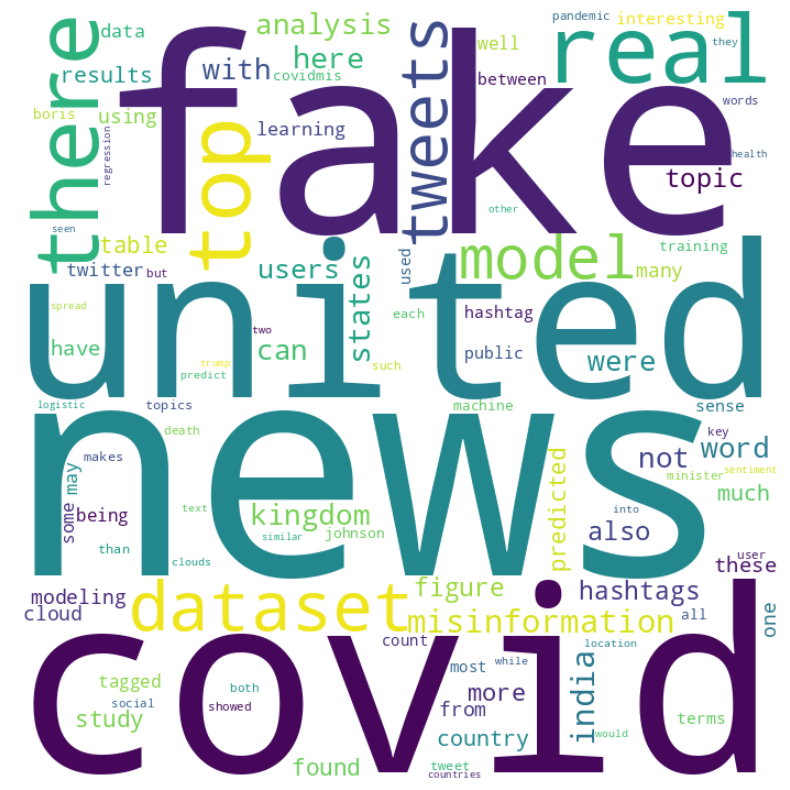

In [15]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Convert the DataFrame to a dictionary
word_freq = {row['word']: row['count'] for row in results2.collect()}

# Create the word cloud
wordcloud = WordCloud(width=700, height=700, background_color='white').generate_from_frequencies(word_freq)

# Display the word cloud using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()